# Unsupervised Learning on U.S. University Data: PCA and K-Means Clustering

**Liqi Liang** | Penn Machine Learning Project (MSSP 6080)

This project applies unsupervised machine learning techniques to a dataset of American universities aggregated from government statistics. The goal is to discover latent structure in institutional characteristics — without using predefined labels — through two complementary methods: Principal Component Analysis (PCA) for dimensionality reduction, and K-Means clustering for grouping similar institutions.

**Dataset:** Government statistics on U.S. colleges and universities, covering enrollment, financial data, selectivity, and instructional staff metrics.

**Methods:** MinMax normalization → PCA (2–10 components) → K-Means clustering (Elbow Method for K selection)

## Setup

In [ ]:
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1lPoKPVXt9glGvBlxA-lwZDtmpyUsvIpL' -O colleges.csv

--2025-03-29 03:36:55--  https://docs.google.com/uc?export=download&id=1lPoKPVXt9glGvBlxA-lwZDtmpyUsvIpL
Resolving docs.google.com (docs.google.com)... 173.194.212.138, 173.194.212.102, 173.194.212.100, ...
Connecting to docs.google.com (docs.google.com)|173.194.212.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1lPoKPVXt9glGvBlxA-lwZDtmpyUsvIpL&export=download [following]
--2025-03-29 03:36:56--  https://drive.usercontent.google.com/download?id=1lPoKPVXt9glGvBlxA-lwZDtmpyUsvIpL&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.204.132, 2607:f8b0:400c:c15::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.204.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1122328 (1.1M) [application/octet-stream]
Saving to: ‘colleges.csv’

colleges.csv        100%[===================>]   1.07M  --.-KB/s 

In [ ]:
import pandas as pd
input_file = pd.read_csv("colleges.csv")
print(input_file.shape)

input_file_clean = {
    "Institution name": input_file["Institution name"]
}
for column in input_file.loc[:, input_file.columns[1:]]:
  clean_column = []
  original_column = input_file[column].replace("-", None)
  for x in original_column:
    try:
      clean_column.append(float(x))
    except:
      clean_column.append(None)
  input_file_clean[column] = clean_column
df = pd.DataFrame(input_file_clean)
df = df.dropna()



(3815, 77)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df.columns

Index(['Institution name', 'Number of Applicants', 'Number Admitted',
       'Number Admitted who Enrolled', 'Percent of Applicants Admitted',
       'Percent Admitted who Enrolled', 'Undergraduate total_Full time - Men',
       'Undergraduate total_Full time - Women',
       'Undergraduate total_Full time - Total',
       'Undergraduate total_Part time - Men',
       'Undergraduate total_Part time - Women',
       'Undergraduate total_Part time - Total',
       'Undergraduate total_Grand Total', 'Graduate_Full time - Men',
       'Graduate_Full time - Women', 'Graduate_Full time - Total',
       'Graduate_Part time - Men', 'Graduate_Part time - Women',
       'Graduate_Part time - Total', 'Graduate_Grand Total',
       'All students total_Full time - Men',
       'All students total_Full time - Women',
       'All students total_Full time - Total',
       'All students total_Part time - Men',
       'All students total_Part time - Women',
       'All students total_Part time - Total',

## 1. Conceptual Feature Grouping

Before applying unsupervised methods, I manually identify four conceptual dimensions that characterize universities: size, selectivity, financial resources, and faculty composition. This provides interpretive anchors for the PCA components and clusters identified later.

**Size:** enrollment totals, degrees granted, full-time instructional staff

**Selectivity:**

*   'Undergraduate total_Grand Total'
*   'Graduate_Grand Total'
*   'All students total_Grand Total'
*   'Degrees granted'
*   'All full-time instructional staff'

**Selectivity**

*   'Number of Applicants'
*   'Percent of Applicants Admitted'
*   'SAT I Verbal - 25th Percentile'
*   'SAT I Verbal - 75th Percentile'
*   'SAT I Math - 25th Percentile'
*   'SAT I Math - 75th Percentile'
*   'Students submitting SAT scores - Percent'
*   'Graduation rate (%)'

**Diversity**

*   'Out-of-state - Percent'
*   'Foreign countries - Percent'
*   'Total_American Indian or Alaska Native '
*   'Total_Asian '
*   'Total_Black or African American '
*   'Total_Hispanic or Latino'
*   'Total_Native Hawaiian or Other Pacific Islander '
*   'Total_White '

**Faculty**: Features representing the composition and academic strength of faculty/staff at the university

*   'All full-time instructional staff'
*   'With faculty status'
*   'With tenure'
*   'On tenure track'
*   'Not on tenure track'

## 2. Data Normalization

All features are normalized to the [0, 1] range using MinMaxScaler before applying PCA or clustering, to prevent high-magnitude variables from dominating the results.

In [ ]:
df_dropname = df.drop(columns=["Institution name"]) #drop the name of the institution
X = df_dropname.loc[:, df_dropname.columns]
df_norm = pd.DataFrame(mms.fit_transform(X), columns=X.columns)
df_norm.head()

,Number of Applicants,Number Admitted,Number Admitted who Enrolled,Percent of Applicants Admitted,Percent Admitted who Enrolled,Undergraduate total_Full time - Men,Undergraduate total_Full time - Women,Undergraduate total_Full time - Total,Undergraduate total_Part time - Men,Undergraduate total_Part time - Women,...,Graduate_Nonresident alien,Total_American Indian or Alaska Native,Total_Asian,Total_Black or African American,Total_Hispanic or Latino,Total_Native Hawaiian or Other Pacific Islander,Total_White,Total_Two or more races,Total_Race/ethnicity unknown,Total_Nonresident alien
0,0.066914,0.207538,0.201699,0.917104,0.345144,0.160819,0.261824,0.207093,0.155167,0.201658,...,0.079623,0.042972,0.108533,0.367405,0.018053,0.025641,0.328252,0.329880,0.013965,0.073326
1,0.037822,0.102288,0.123622,0.799580,0.440945,0.148318,0.113675,0.129643,0.080409,0.045458,...,0.030668,0.070648,0.030273,0.072485,0.012304,0.025641,0.172459,0.097610,0.018507,0.031385
2,0.066368,0.218828,0.087746,0.975866,0.106299,0.053714,0.095749,0.071274,0.012279,0.012048,...,0.002045,0.003642,0.001830,0.307793,0.001155,0.008547,0.004345,0.017530,0.002464,0.004054
3,0.326438,0.646261,0.596060,0.570829,0.324147,0.537664,0.714349,0.621917,0.135825,0.186790,...,0.061677,0.101238,0.038756,0.309402,0.049189,0.179487,0.741057,0.494821,0.011597,0.085559
4,0.050139,0.156809,0.062353,0.924449,0.107612,0.048754,0.097258,0.069385,0.042052,0.058532,...,0.006020,0.014567,0.009897,0.161060,0.001666,0.012821,0.057927,0.106773,0.003962,0.019223


## 3. Dimensionality Reduction via PCA

### 3.1 Variance Explained by Number of Components

I vary the number of PCA components from 2 to 10 to identify a suitable reduced representation. The goal is to retain enough variance to be informative while achieving meaningful compression.

In [ ]:
for i in range(2, 11):
  pca = PCA(n_components = i)
  pca.fit(df_norm)
  variance_explained_percentage = sum(pca.explained_variance_ratio_)*100 #Convert decimals to percentages
  print(f"Number of components: {i}, Variance explained: {variance_explained_percentage:.2f}%") #Keep two decimal places

Number of components: 2, Variance explained: 64.18%
Number of components: 3, Variance explained: 71.86%
Number of components: 4, Variance explained: 75.97%
Number of components: 5, Variance explained: 79.32%
Number of components: 6, Variance explained: 82.34%
Number of components: 7, Variance explained: 84.79%
Number of components: 8, Variance explained: 86.91%
Number of components: 9, Variance explained: 88.54%
Number of components: 10, Variance explained: 90.05%


### 3.2 Component Interpretation (4 Components)

Setting n_components = 4, I examine feature loadings for each component to interpret what institutional dimension each component captures.

In [ ]:
pca = PCA(n_components = 4)
components = pca.fit_transform(df_norm)

In [ ]:
#Exploring Component 1
# Component 1
factors_c1 = pd.DataFrame({
    "Features": df_norm.columns,
    "Component 1": pca.components_[0]
})
factors_c1.sort_values("Component 1", ascending=False, ignore_index=True, inplace=True)

print(f"The top 3 in Component 1 are {factors_c1.iloc[0, 0]}, {factors_c1.iloc[1, 0]}, and {factors_c1.iloc[2, 0]}.")

The top 3 in Component 1 are All students total_Full time - Women, Total_Two or more races , and Undergraduate total_Full time - Women.


In [ ]:
#Exploring Component 2
# Component 2
factors_c2 = pd.DataFrame({
    "Features": df_norm.columns,
    "Component 2": pca.components_[1]
})
factors_c2.sort_values("Component 2", ascending=False, ignore_index=True, inplace=True)

print(f"The top 3 in Component 2 are {factors_c2.iloc[0, 0]}, {factors_c2.iloc[1, 0]}, and {factors_c2.iloc[2, 0]}.")

The top 3 in Component 2 are In-state - Percent, Transfer-out rate (%), and Percent of Applicants Admitted.


In [ ]:
#Exploring Component 3
# Component 3
factors_c3 = pd.DataFrame({
    "Features": df_norm.columns,
    "Component 3": pca.components_[2]
})
factors_c3.sort_values("Component 3", ascending=False, ignore_index=True, inplace=True)

print(f"The top 3 in Component 3 are {factors_c3.iloc[0, 0]}, {factors_c3.iloc[1, 0]}, and {factors_c3.iloc[2, 0]}.")

The top 3 in Component 3 are Students submitting SAT scores - Percent, Graduation rate (%), and Students submitting SAT scores - Number.


In [ ]:
#Exploring Component 4
# Component 4
factors_c4 = pd.DataFrame({
    "Features": df_norm.columns,
    "Component 4": pca.components_[3]
})
factors_c4.sort_values("Component 4", ascending=False, ignore_index=True, inplace=True)

print(f"The top 3 in Component 4 are {factors_c4.iloc[0, 0]}, {factors_c4.iloc[1, 0]}, and {factors_c4.iloc[2, 0]}.")

The top 3 in Component 4 are Graduation rate (%), Undergraduate_White , and Number Admitted.


## 4. K-Means Clustering

### 4.1 Choosing K via the Elbow Method

I apply K-Means to the PCA-reduced representation and use the Elbow Method to select the optimal number of clusters, balancing within-cluster variance against model complexity.

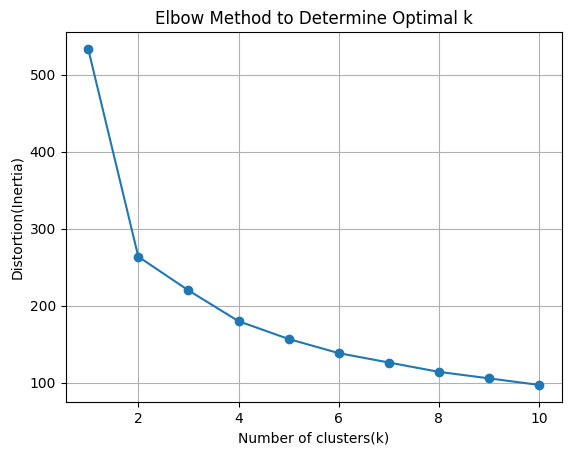

In [ ]:
#Form the dataframe on which to tune the model
condensed_df = pd.DataFrame(components, index=df['Institution name'])
# Use 'Institution name' as index

# Use elbow method to describe how many clusters is appropriate
distortions = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=300, random_state=123)
    km.fit(condensed_df)
    distortions.append(km.inertia_)

# show the plot
plt.plot(range(1, 11), distortions, marker='o')
plt.xlabel('Number of clusters(k)')
plt.ylabel('Distortion(Inertia)')
plt.title('Elbow Method to Determine Optimal k')
plt.grid()
plt.show()

### 4.2 Final Clustering with K = 4

In [ ]:
km = KMeans(n_clusters=4,
                init='k-means++',
                n_init=10,
                max_iter=300,
                random_state=123)
km_predict = km.fit_predict(condensed_df)
df["Cluster_Prediction"] = km_predict

for i in range(0, 4):
  df_i = df.loc[df["Cluster_Prediction"] == i]
  print(f"Cluster {i+1} stats:")
  print(f"Percentage of all data: {round(100*len(df_i)/len(df), 2)}%")
  print(f"Average percent of applicants admitted: {round(100*np.mean(df_i['Percent of Applicants Admitted']), 2)}")
  print(f"Average total number of undergrads: {round(np.mean(df_i['Undergraduate_Total']), 2)}")
  print(f"Average 75th percentile marker for SAT I Math: {round(np.mean(df_i['SAT I Math - 75th Percentile']), 2)}")
  print(f"Average percent of in-state students: {round(100*np.mean(df_i['In-state - Percent']), 2)}")
  print()

Cluster 1 stats:
Percentage of all data: 7.76%
Average percent of applicants admitted: 49.92
Average total number of undergrads: 31867.82
Average 75th percentile marker for SAT I Math: 701.18
Average percent of in-state students: 68.89

Cluster 2 stats:
Percentage of all data: 17.35%
Average percent of applicants admitted: 68.27
Average total number of undergrads: 20558.58
Average 75th percentile marker for SAT I Math: 626.12
Average percent of in-state students: 84.95

Cluster 3 stats:
Percentage of all data: 58.9%
Average percent of applicants admitted: 72.42
Average total number of undergrads: 4584.03
Average 75th percentile marker for SAT I Math: 577.03
Average percent of in-state students: 78.9

Cluster 4 stats:
Percentage of all data: 15.98%
Average percent of applicants admitted: 59.23
Average total number of undergrads: 4010.56
Average 75th percentile marker for SAT I Math: 678.23
Average percent of in-state students: 34.42



## 5. Results and Interpretation

### 5.1 What number of clusters did you choose, and what was your evaluation process for choosing that value?

I chose 4 clusters based on the Elbow Method plot. The reduction from 2 to 3 and from 3 to 4 is relatively large, whereas the reduction from 4 to 5 is comparatively small. Therefore, choosing 4 clusters is reasonable, though selecting 3 clusters would also be a good option.







### 3.2 Do the sets of features you chose manually align with the principal components

and/**or clusters you discovered?**

**Component 1:**

All students total_Full time - Women,**(not manual selected)**

Total_Two or more races,**(not manual selected)**

Undergraduate total_Full time - Women. **(not manual selected)**

**Component 2:**

In-state - Percent, **(not manual selected)**

Transfer-out rate (%), **(not manual selected)**

Percent of Applicants Admitted. **(Selectivity)**

**Component 3:**

Students submitting SAT scores - Percent, **(Selectivity)**

Graduation rate (%), **(Selectivity)**

Students submitting SAT scores - Number. **(not manual selected)**

**Component 4:**

Graduation rate (%),  **(Selectivity)**

Undergraduate_White, **(not manual selected)**

Number Admitted. **(not manual selected)**

Among the variables selected by PCA, only “Percent of Applicants Admitted”, “Students submitting SAT scores - Percent”, and “Graduation rate (%)” were also manually selected earlier, with “Graduation rate (%)” appearing twice.
And these three variables all belong to the Selectivity category.

Additionally, “In-state - Percent” can also be considered as selected, since “Out-of-state - Percent” was included in our manual selection.

Among the variables that were not manually selected, two are related to gender: “All students total_Full time - Women” and “Undergraduate total_Full time - Women”, as well as race: “Undergraduate_White”.

Additionally, in our manual selection we tended to use percentages, whereas the variables in the not-manually-selected set included absolute numbers, such as “Number Admitted” and “Students submitting SAT scores - Number”.







### 3.3 What additional features, not present in this data, would be useful to group together similar universities using unsupervised learning?

I believe Financial Aid Information is a very important indicator, as it determines whether certain students can afford the cost of attending college or graduate school. Related variables might include the estimated cost of attendance.

Besides, employment rate and post-graduation salary are also important metrics—especially in the current job market conditions.

Additional features related to faculty could also be very helpful. For example, the Student-to-Faculty Ratio and Average Class Size are both important indicators of the level of instructional attention and academic environment.